<a href="https://colab.research.google.com/github/KhytsenkoIgor/python-data-analysis-tasks/blob/main/HW_11_2_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

**Підготовка даних:**

In [3]:
monthly_rentals = df[['count']].resample('ME').mean()  # Групуємо дані помісячно та розраховуємо середню кількість оренд

monthly_rentals.head()  # Перевіряємо перші 5 рядків отриманого результату

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211


**1.Побудова графіка за допомогою Pandas**

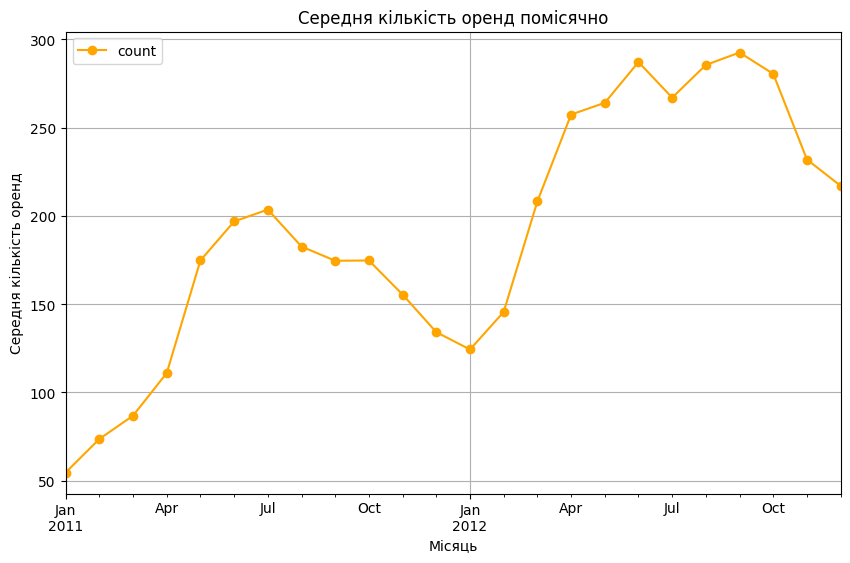

In [4]:
monthly_rentals.plot(  # Будуємо лінійний графік середньої кількості оренд помісячно
    figsize=(10, 6),   # Задаємо розмір графіка
    marker='o',        # Додаємо маркери-кружечки на кожну точку
    color='orange',    # Задаємо колір лінії
    title='Середня кількість оренд помісячно'  # Додаємо заголовок графіка
)

plt.xlabel('Місяць')  # Підписуємо вісь X
plt.ylabel('Середня кількість оренд')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого читання значень
plt.show()  # Виводимо готовий графік

**2.Побудова лінійного графіка через Matplotlib**

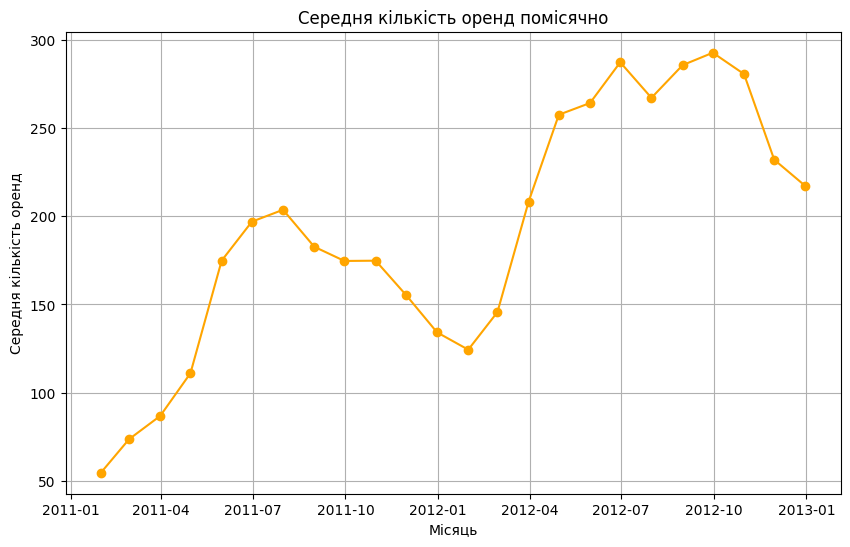

In [5]:
plt.figure(figsize=(10, 6))  # Створюємо область графіка та задаємо її розмір

plt.plot(
    monthly_rentals.index,       # Передаємо місяці на вісь X
    monthly_rentals['count'],    # Передаємо середню кількість оренд на вісь Y
    marker='o',                  # Додаємо маркери-кружечки
    color='orange'               # Задаємо колір лінії
)

plt.title('Середня кількість оренд помісячно')  # Додаємо заголовок графіка
plt.xlabel('Місяць')  # Підписуємо вісь X
plt.ylabel('Середня кількість оренд')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого читання графіка
plt.show()  # Виводимо готовий графік

**Спостереження:**

Обидва графіки відображають одні і тіж дані та мають практично однаковий вигляд. Основна різниця полягає у способі побудови: у Pandas графік створюється швидше та потребує менше коду а в Matplotlib потрібно окремо задавати основні елементи графіка.Але Matplotlib дає більше можливостей для детального налаштування візуалізації та тонких налоштувань.

Мені більше подобається графік побудований за допомогою Matplotlib, тому що він виглядає більш охайним та науковим,і ще  можно точніше контролювати його вигляд та окремі елементи.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [6]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

**Лінійний графік: Продажі за два тижні**

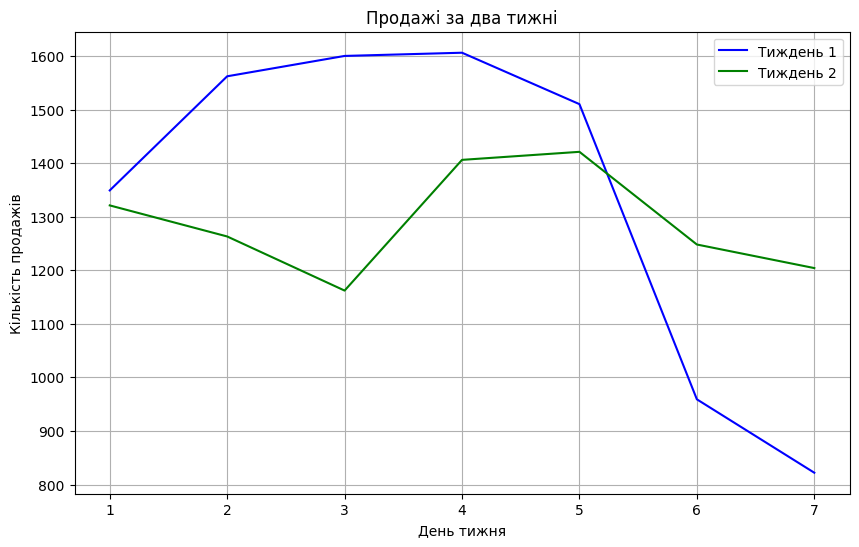

In [7]:
plt.figure(figsize=(10, 6))  # Створюємо область для графіка та задаємо її розмір

plt.plot(days, sales_week1, color='blue', label='Тиждень 1')  # Будуємо лінію продажів за перший тиждень
plt.plot(days, sales_week2, color='green', label='Тиждень 2')  # Будуємо лінію продажів за другий тиждень іншим кольором

plt.title('Продажі за два тижні')  # Додаємо назву графіка
plt.xlabel('День тижня')  # Підписуємо вісь X
plt.ylabel('Кількість продажів')  # Підписуємо вісь Y

plt.legend()  # Додаємо легенду, щоб розрізняти два ряди даних
plt.grid(True)  # Додаємо сітку для зручнішого порівняння значень

plt.show()  # Виводимо готовий графік

**Лінійний графік: Продажі за два тижні з деталізацією**

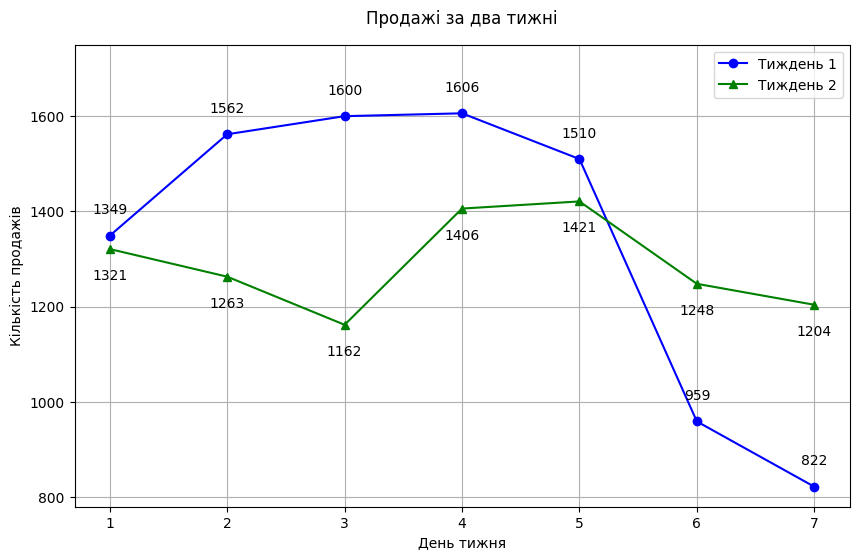

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))  # Створюємо фігуру та область для побудови графіка

ax.plot(days, sales_week1, 'b-o', label='Тиждень 1')  # Будуємо синю суцільну лінію з маркерами-кружечками
ax.plot(days, sales_week2, 'g-^', label='Тиждень 2')  # Будуємо зелену суцільну лінію з маркерами-трикутниками

for day, sale in zip(days, sales_week1):  # Перебираємо значення продажів першого тижня
    ax.annotate(str(sale), xy=(day, sale), xytext=(day, sale + 45), ha='center')  # Виводимо значення над точкою

for day, sale in zip(days, sales_week2):  # Перебираємо значення продажів другого тижня
    ax.annotate(str(sale), xy=(day, sale), xytext=(day, sale - 65), ha='center')  # Виводимо значення під точкою

ax.set_ylim(780, 1750)  # Залишаємо додаткове вільне місце зверху для підписів

ax.set_title('Продажі за два тижні', pad=15)  # Додаємо відступ між заголовком і графіком
ax.set_xlabel('День тижня')  # Підписуємо вісь X
ax.set_ylabel('Кількість продажів')  # Підписуємо вісь Y

ax.legend()  # Додаємо легенду
ax.grid(True)  # Додаємо сітку

plt.show()  # Виводимо готовий графік

**Відповідь:**

1.   Стабільнішими були продажі у другий тиждень. На графіку видно, що значення другого тижня змінюються в значно меншому діапазоні, тоді як у першому тижні після 5 -го дня відбувається різке падіння продажів.
2.   Висновок можна підтвердити обчисленнями, наприклад за допомогою стандартного відхилення та розмаху:



In [9]:
print('Тиждень 1:', round(np.std(sales_week1), 2))  # Виводимо стандартне відхилення першого тижня
print('Тиждень 2:', round(np.std(sales_week2), 2))  # Виводимо стандартне відхилення другого тижня

Тиждень 1: 300.0
Тиждень 2: 90.91


In [10]:
print('Тиждень 1:', max(sales_week1) - min(sales_week1))  # Виводимо розмах продажів першого тижня
print('Тиждень 2:', max(sales_week2) - min(sales_week2))  # Виводимо розмах продажів другого тижня

Тиждень 1: 784
Тиждень 2: 259


**Висновок за розрахунками:**
*    Продажі були стабільнішими у другий тиждень. Це підтверджується як графіком, так і за розрахунками. Стандартне відхилення у другий тиждень становить приблизно 90,91 а у перший  300,0. Також розмах продажів у другий тиждень дорівнює 259, перший тиждень 784. Менші значення стандартного відхилення та розмаху означають, що продажі у другий тиждень коливалися значно менше були більш стабільними.






## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [11]:
monthly_temp = df['temp'].resample('ME').mean()  # Розраховуємо середню температуру для кожного місяця

quarterly_rentals = df.groupby('season')['count'].mean()  # Розраховуємо середню годинну кількість оренд для кожного кварталу

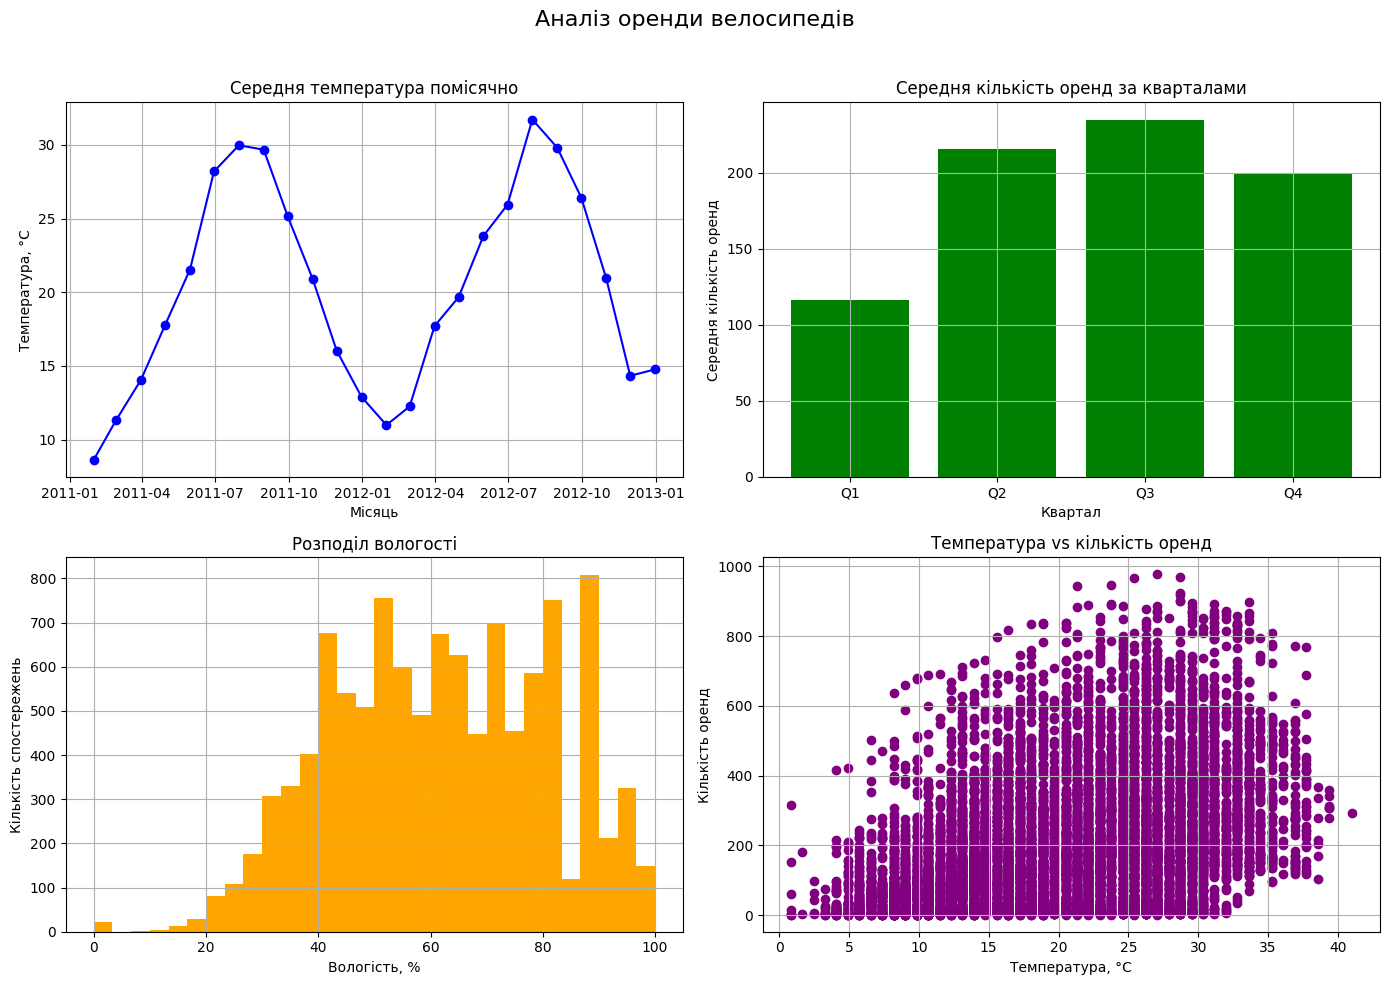

In [12]:
plt.figure(figsize=(14, 10))  # Створюємо спільну фігуру для чотирьох графіків та задаємо її розмір


plt.subplot(2, 2, 1)  # Створюємо перший графік у верхній лівій частині сітки 2x2
plt.plot(monthly_temp.index, monthly_temp.values, 'b-o')  # Будуємо лінійний графік середньої температури по місяцях
plt.title('Середня температура помісячно')  # Додаємо назву першого графіка
plt.xlabel('Місяць')  # Підписуємо вісь X
plt.ylabel('Температура, °C')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого читання графіка


plt.subplot(2, 2, 2)  # Створюємо другий графік у верхній правій частині сітки 2x2
plt.bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_rentals.values, color='green')  # Будуємо стовпчикову діаграму середньої кількості оренд за кварталами
plt.title('Середня кількість оренд за кварталами')  # Додаємо назву другого графіка
plt.xlabel('Квартал')  # Підписуємо вісь X
plt.ylabel('Середня кількість оренд')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого порівняння значень


plt.subplot(2, 2, 3)  # Створюємо третій графік у нижній лівій частині сітки 2x2
plt.hist(df['humidity'], bins=30, color='orange')  # Будуємо гістограму розподілу вологості за всіма погодинними вимірами
plt.title('Розподіл вологості')  # Додаємо назву третього графіка
plt.xlabel('Вологість, %')  # Підписуємо вісь X
plt.ylabel('Кількість спостережень')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого читання гістограми


plt.subplot(2, 2, 4)  # Створюємо четвертий графік у нижній правій частині сітки 2x2
plt.scatter(df['temp'], df['count'], color='purple')  # Будуємо точковий графік залежності кількості оренд від температури
plt.title('Температура vs кількість оренд')  # Додаємо назву четвертого графіка
plt.xlabel('Температура, °C')  # Підписуємо вісь X
plt.ylabel('Кількість оренд')  # Підписуємо вісь Y
plt.grid(True)  # Додаємо сітку для зручнішого аналізу залежності


plt.suptitle('Аналіз оренди велосипедів', fontsize=16)  # Додаємо спільну назву для всього дашборду

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Налаштовуємо відступи, щоб графіки та загальний заголовок не накладалися

plt.show()  # Виводимо готовий дашборд з чотирма графіками

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

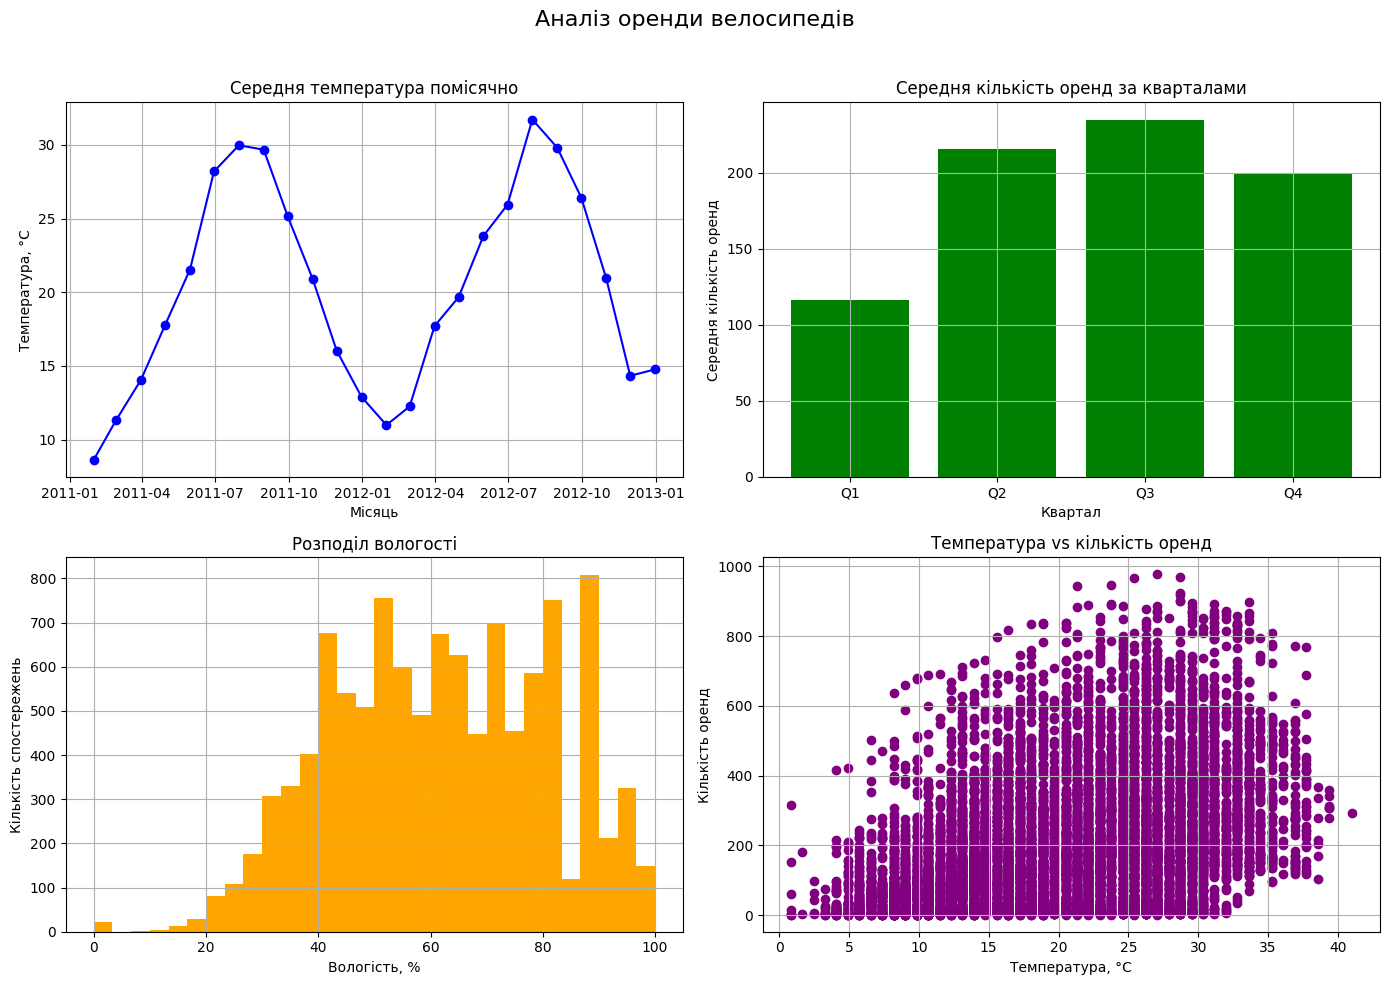

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))  # Створюємо фігуру з чотирма графіками у сітці 2x2


ax[0, 0].plot(monthly_temp.index, monthly_temp.values, 'b-o')  # Будуємо лінійний графік середньої температури помісячно
ax[0, 0].set_title('Середня температура помісячно')  # Додаємо назву першого графіка
ax[0, 0].set_xlabel('Місяць')  # Підписуємо вісь X першого графіка
ax[0, 0].set_ylabel('Температура, °C')  # Підписуємо вісь Y першого графіка
ax[0, 0].grid(True)  # Додаємо сітку до першого графіка


ax[0, 1].bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_rentals.values, color='green')  # Будуємо стовпчикову діаграму середньої кількості оренд за кварталами
ax[0, 1].set_title('Середня кількість оренд за кварталами')  # Додаємо назву другого графіка
ax[0, 1].set_xlabel('Квартал')  # Підписуємо вісь X другого графіка
ax[0, 1].set_ylabel('Середня кількість оренд')  # Підписуємо вісь Y другого графіка
ax[0, 1].grid(True)  # Додаємо сітку до другого графіка


ax[1, 0].hist(df['humidity'], bins=30, color='orange')  # Будуємо гістограму вологості за всіма погодинними вимірами
ax[1, 0].set_title('Розподіл вологості')  # Додаємо назву третього графіка
ax[1, 0].set_xlabel('Вологість, %')  # Підписуємо вісь X третього графіка
ax[1, 0].set_ylabel('Кількість спостережень')  # Підписуємо вісь Y третього графіка
ax[1, 0].grid(True)  # Додаємо сітку до третього графіка


ax[1, 1].scatter(df['temp'], df['count'], color='purple')  # Будуємо точковий графік залежності кількості оренд від температури
ax[1, 1].set_title('Температура vs кількість оренд')  # Додаємо назву четвертого графіка
ax[1, 1].set_xlabel('Температура, °C')  # Підписуємо вісь X четвертого графіка
ax[1, 1].set_ylabel('Кількість оренд')  # Підписуємо вісь Y четвертого графіка
ax[1, 1].grid(True)  # Додаємо сітку до четвертого графіка


fig.suptitle('Аналіз оренди велосипедів', fontsize=16)  # Додаємо спільну назву для всього дашборду

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Налаштовуємо відступи, щоб графіки та заголовок не накладалися

plt.show()  # Виводимо готову сітку з чотирьох графіків

**Відповідь:**

*   plt.subplot() працює з графіками послідовно: ми щоразу вказуємо номер потрібної області, наприклад plt.subplot(2, 2, 1), після чого всі наступні команди застосовуються до неї.

plt.subplots() одразу створює фігуру та набір об'єктів Axes, тому до кожного графіка можна звертатися напряму, наприклад ax[0, 0], ax[0, 1]. Через це код стає більш зрозумілим і зручним для керування кількома графіками.

Мені більше подобається plt.subplots(), тому що при роботі з декількома графіками чітко видно, до якого саме графіка застосовується кожна команда. Це також відповідає поясненню в лекції: plt.subplot() має неявний доступ до поточної осі, а plt.subplots() — явний доступ через ax[i, j].




## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [14]:
import matplotlib.dates as mdates  # Підключаємо модуль Matplotlib для форматування дат на осі X

monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])  # Розраховуємо середнє, максимум і мінімум оренд для кожного місяця

overall_mean = df['count'].mean()  # Розраховуємо середню кількість оренд за весь період
overall_min = df['count'].min()  # Визначаємо найменшу кількість оренд у всьому датасеті
overall_max = df['count'].max()  # Визначаємо найбільшу кількість оренд у всьому датасеті
overall_std = df['count'].std()  # Розраховуємо стандартне відхилення кількості оренд

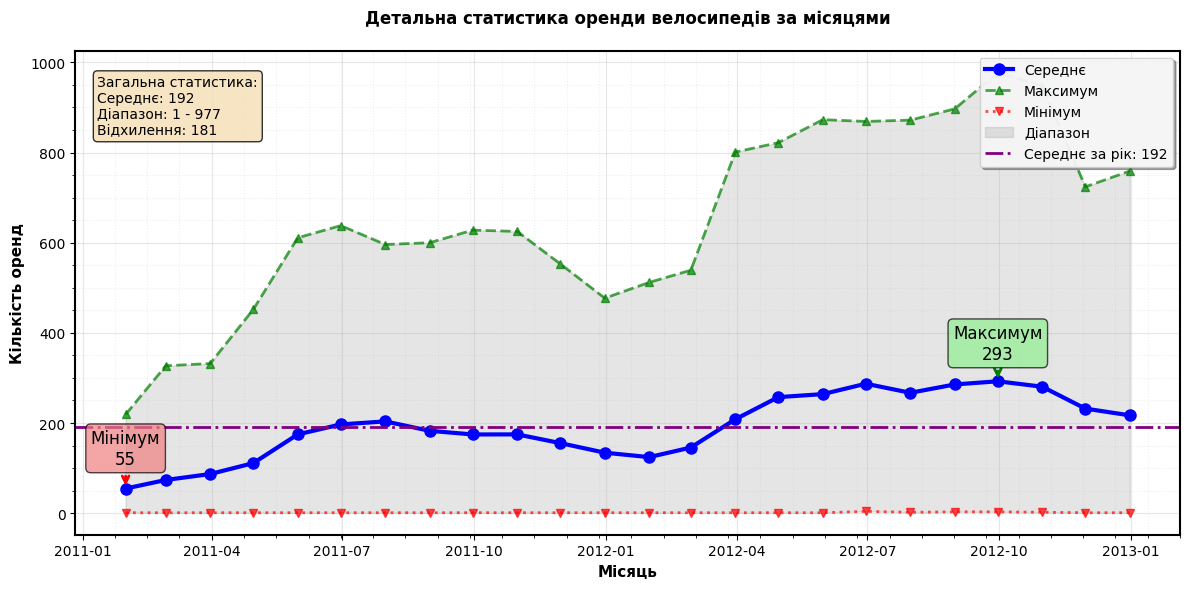

In [ ]:
import matplotlib.dates as mdates  # Підключаємо модуль Matplotlib для форматування дат на осі X

monthly_stats = df['count'].resample('ME').agg(['mean', 'max', 'min'])  # Розраховуємо середнє, максимум і мінімум оренд за кожен місяць

overall_mean = df['count'].mean()  # Розраховуємо середню кількість оренд за весь період
overall_min = df['count'].min()  # Визначаємо мінімальну кількість оренд за весь період
overall_max = df['count'].max()  # Визначаємо максимальну кількість оренд за весь період
overall_std = df['count'].std()  # Розраховуємо стандартне відхилення кількості оренд


fig, ax = plt.subplots(figsize=(12, 6))  # Створюємо фігуру та задаємо розмір, близький до зразка


ax.plot(monthly_stats.index, monthly_stats['mean'], 'b-o',
        linewidth=3, label='Середнє', markersize=8)  # Будуємо синю суцільну лінію середніх значень з кружечками

ax.plot(monthly_stats.index, monthly_stats['max'], 'g--^',
        linewidth=2, label='Максимум', markersize=6, alpha=0.7)  # Будуємо зелену пунктирну лінію максимальних значень з трикутниками

ax.plot(monthly_stats.index, monthly_stats['min'], 'r:v',
        linewidth=2, label='Мінімум', markersize=6, alpha=0.7)  # Будуємо червону крапкову лінію мінімальних значень з перевернутими трикутниками


ax.fill_between(monthly_stats.index,
                monthly_stats['min'],
                monthly_stats['max'],
                alpha=0.2, color='gray', label='Діапазон')  # Зафарбовуємо область між мінімальними та максимальними значеннями


max_mean_idx = monthly_stats['mean'].idxmax()  # Знаходимо місяць з найбільшим середнім значенням оренд
max_mean_val = monthly_stats['mean'].max()  # Визначаємо найбільше середнє значення оренд

min_mean_idx = monthly_stats['mean'].idxmin()  # Знаходимо місяць з найменшим середнім значенням оренд
min_mean_val = monthly_stats['mean'].min()  # Визначаємо найменше середнє значення оренд


ax.annotate(f'Максимум\n{max_mean_val:.0f}',
            xy=(max_mean_idx, max_mean_val),
            xytext=(max_mean_idx, max_mean_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))  # Додаємо анотацію до найбільшого середнього значення


ax.annotate(f'Мінімум\n{min_mean_val:.0f}',
            xy=(min_mean_idx, min_mean_val),
            xytext=(min_mean_idx, min_mean_val + 55),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))  # Додаємо анотацію до найменшого середнього значення


ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')  # Додаємо горизонтальну лінію середнього значення


ax.set_title('Детальна статистика оренди велосипедів за місяцями',
             fontsize=12, fontweight='bold', pad=20)  # Додаємо заголовок графіка жирним шрифтом

ax.set_xlabel('Місяць',
              fontsize=11, fontweight='bold')  # Підписуємо вісь X жирним шрифтом

ax.set_ylabel('Кількість оренд',
              fontsize=11, fontweight='bold')  # Підписуємо вісь Y жирним шрифтом


ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Відображаємо дати на осі X у форматі рік-місяць

ax.xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 4, 7, 10])
)  # Виводимо основні підписи для січня, квітня, липня та жовтня

ax.tick_params(axis='x', rotation=0)  # Розміщуємо підписи дат горизонтально, як у зразку


ax.grid(True, which='major',
        linestyle='-', alpha=0.3)  # Додаємо основну сітку суцільними лініями

ax.grid(True, which='minor',
        linestyle=':', alpha=0.2)  # Додаємо допоміжну сітку крапковими лініями

ax.minorticks_on()  # Вмикаємо допоміжні поділки для другої сітки


ax.legend(loc='upper right',
          fontsize=10,
          frameon=True,
          shadow=True,
          fancybox=True,
          framealpha=0.9)  # Додаємо стилізовану легенду з рамкою та тінню


textstr = (
    f'Загальна статистика:\n'
    f'Середнє: {overall_mean:.0f}\n'
    f'Діапазон: {overall_min:.0f} - {overall_max:.0f}\n'
    f'Відхилення: {overall_std:.0f}'
)  # Формуємо текстовий блок із загальною статистикою


props = dict(boxstyle='round',
             facecolor='wheat',
             alpha=0.8)  # Задаємо оформлення текстового блоку


ax.text(0.02, 0.95,
        textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=props)  # Розміщуємо блок зі статистикою у верхньому лівому куті


for spine in ax.spines.values():  # Перебираємо всі рамки навколо області графіка
    spine.set_linewidth(1.5)  # Робимо рамки графіка трохи товстішими


plt.tight_layout()  # Автоматично налаштовуємо відступи між елементами графіка

plt.show()  # Виводимо готовий графік

**Відповідь:**


1. *Яка перевага додавання анотацій на графік?*


*   Анотації допомагають виділити важливі точки на графіку та одразу показати їх значення. У нашому випадку вони акцентують увагу на максимальному та мінімальному середньому значенні оренд.



2. *Для чого використовується fill_between()?*


*   fill_between() використовується для заливки області між двома лініями. У нашому графіку він показує діапазон між мінімальною та максимальною кількістю оренд за кожен місяць.



3. *Як текстовий блок допомагає в інтерпретації даних?*


*   Текстовий блок допомагає швидко побачити основні статистичні показники без додаткових розрахунків. У нашому графіку в ньому відображаються середнє значення, загальний діапазон та стандартне відхилення.





